## How Are In-Demand Skills Trending For Data Analyst

In [64]:
#Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from ast import literal_eval

#Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x:literal_eval(x) if pd.notna(x) else x)

In [65]:
df_DA_US = df[(df['job_title'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_DA_US['job_posted_month'] = df_DA_US['job_posted_date'].dt.month
df_DA_US = df_DA_US.explode('job_skills')
df_DA_US

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month
36,Data Analyst,Data Analyst,"Des Moines, IA",via Trabajo.org,Full-time,False,"Illinois, United States",2023-11-06 13:01:22,False,True,United States,None,NaN,NaN,Assuredpartners,None,None,11
155,Data Analyst,Data Analyst,"Tampa, FL",via LinkedIn,Full-time,False,"Florida, United States",2023-01-19 13:19:45,False,False,United States,None,NaN,NaN,Citi,sql,"{'analyst_tools': ['excel'], 'async': ['jira']...",1
155,Data Analyst,Data Analyst,"Tampa, FL",via LinkedIn,Full-time,False,"Florida, United States",2023-01-19 13:19:45,False,False,United States,None,NaN,NaN,Citi,python,"{'analyst_tools': ['excel'], 'async': ['jira']...",1
155,Data Analyst,Data Analyst,"Tampa, FL",via LinkedIn,Full-time,False,"Florida, United States",2023-01-19 13:19:45,False,False,United States,None,NaN,NaN,Citi,unix,"{'analyst_tools': ['excel'], 'async': ['jira']...",1
155,Data Analyst,Data Analyst,"Tampa, FL",via LinkedIn,Full-time,False,"Florida, United States",2023-01-19 13:19:45,False,False,United States,None,NaN,NaN,Citi,excel,"{'analyst_tools': ['excel'], 'async': ['jira']...",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785539,Data Analyst,Data Analyst,"Fairfax Station, VA",via Monster,Full-time,False,"New York, United States",2023-01-06 05:59:59,False,True,United States,None,NaN,NaN,Guidehouse,databricks,"{'analyst_tools': ['tableau', 'excel'], 'cloud...",1
785539,Data Analyst,Data Analyst,"Fairfax Station, VA",via Monster,Full-time,False,"New York, United States",2023-01-06 05:59:59,False,True,United States,None,NaN,NaN,Guidehouse,tableau,"{'analyst_tools': ['tableau', 'excel'], 'cloud...",1
785539,Data Analyst,Data Analyst,"Fairfax Station, VA",via Monster,Full-time,False,"New York, United States",2023-01-06 05:59:59,False,True,United States,None,NaN,NaN,Guidehouse,excel,"{'analyst_tools': ['tableau', 'excel'], 'cloud...",1
785685,Data Analyst,Data Analyst,"Indianapolis, IN",via Trabajo.org,Full-time,False,"Illinois, United States",2023-07-16 06:01:27,True,False,United States,None,NaN,NaN,"Aara Technologies, Inc",sql,"{'analyst_tools': ['excel'], 'programming': ['...",7


In [66]:
df_DA_US_pivot  = df_DA_US.pivot_table(index='job_posted_month',columns='job_skills',aggfunc='size',fill_value=0)
df_DA_US_pivot.loc['total'] = df_DA_US_pivot.sum()
df_DA_US_pivot = df_DA_US_pivot[df_DA_US_pivot.loc['total'].sort_values(ascending=False).index]
df_DA_US_pivot = df_DA_US_pivot.drop('total')
df_DA_US_pivot


job_skills,sql,excel,tableau,python,power bi,sas,r,word,powerpoint,oracle,...,mariadb,mxnet,next.js,ringcentral,sqlserver,svelte,theano,tidyr,symphony,yarn
job_posted_month,,,,,,,,,,,,,,,,,,,,,
1,1138,781,646,529,326,394,338,169,176,164,...,0,0,0,1,0,0,0,0,0,0
2,782,544,408,378,302,270,233,128,130,99,...,0,0,0,0,0,0,0,0,0,0
3,802,580,463,400,277,300,241,142,127,107,...,0,0,0,0,0,0,0,0,0,0
4,845,577,462,421,292,258,238,143,133,122,...,0,0,0,0,0,0,0,0,0,0
5,706,490,367,336,251,206,219,92,119,98,...,1,0,0,0,0,0,0,0,0,0
6,742,491,395,396,272,202,252,126,116,99,...,0,0,0,0,0,0,0,0,0,0
7,560,431,296,292,190,182,188,101,101,62,...,0,0,1,0,1,0,0,0,0,1
8,784,641,480,460,292,272,321,112,133,98,...,0,0,0,0,0,0,0,0,0,0
9,485,336,277,253,183,150,157,65,53,67,...,0,0,0,0,0,0,0,0,1,0


In [67]:
DA_totals = df_DA_US.groupby('job_posted_month').size()
DA_totals

job_posted_month
1     7291
2     5231
3     5472
4     5656
5     4555
6     4923
7     3821
8     5614
9     3277
10    3624
11    2978
12    3278
dtype: int64

In [82]:
df_DA_US_percent = df_DA_US_pivot.div(DA_totals/100,axis=0)
df_DA_US_percent = df_DA_US_percent.reset_index()
df_DA_US_percent['job_posted_month_name'] = pd.to_datetime(df_DA_US_percent['job_posted_month'],format='%m').dt.strftime('%b')
df_DA_US_percent = df_DA_US_percent.set_index('job_posted_month_name')
df_DA_US_percent = df_DA_US_percent.drop(columns='job_posted_month')

df_DA_US_percent_top_5 = df_DA_US_percent.iloc[:,:5]
df_DA_US_percent_top_5 


job_skills,sql,excel,tableau,python,power bi
job_posted_month_name,,,,,
Jan,15.608284,10.711837,8.860239,7.255521,4.471266
Feb,14.949340,10.399541,7.799656,7.226152,5.773275
Mar,14.656433,10.599415,8.461257,7.309942,5.062135
Apr,14.939887,10.201556,8.168317,7.443423,5.162659
May,15.499451,10.757409,8.057080,7.376509,5.510428
Jun,15.072111,9.973593,8.023563,8.043876,5.525086
Jul,14.655849,11.279770,7.746663,7.641979,4.972520
Aug,13.965087,11.417884,8.550053,8.193801,5.201283
Sep,14.800122,10.253280,8.452853,7.720476,5.584376


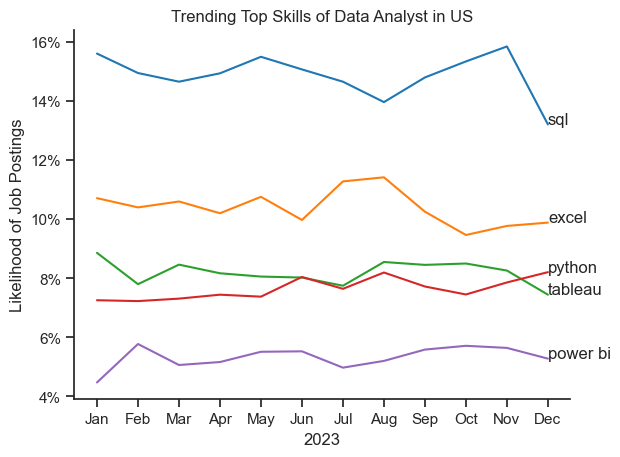

In [116]:
#df_DA_US_percent_top_5.plot(kind='line',legend=False)
sns.lineplot(data=df_DA_US_percent_top_5,legend=False, dashes=False,palette='tab10')
sns.set_theme(style='ticks')
sns.despine()
plt.xlabel('2023')
plt.ylabel('Likelihood of Job Postings')
plt.title('Trending Top Skills of Data Analyst in US')
ax=plt.gca()
#ax.yaxis.set_major_formatter(plt.FuncFormatter (lambda x,pos: f'{x:.0f}%'))
from matplotlib.ticker import PercentFormatter
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

for i in range(5):
    plt.text(11,df_DA_US_percent_top_5.iloc[-1,i],df_DA_US_percent_top_5.columns[i])